## Variant A.6:
gram matrix only
fixed features



In [1]:
from utils import *
from sparse_mc import SparseMountainCar
import flax.struct

config['ENV_NAME'] = "SparseMountainCar-v0"

class Explore_Transition(NamedTuple):
    done: jnp.ndarray
    action: jnp.ndarray
    value: jnp.ndarray
    reward: jnp.ndarray
    log_prob: jnp.ndarray
    obs: jnp.ndarray
    next_obs: jnp.ndarray
    info: jnp.ndarray

def gram_matrix_update( 
                    cov_state: Dict,
                    features: jnp.ndarray, # (Batch, k)
                    config: Dict,
                    α: float, # ema coefficient
    ):
    "Updates the Gram Matrix (Feature Covariance) using EMA"
    
    # S = E[ φ φ^T ]
    def per_sample_gram(feature):
        return jnp.outer(feature, feature)
    
    # --------- Update Logic ---------
    S, t = cov_state['S'], cov_state['t']
    batch_axes = (0,1)
    
    # 1. Calculate Batch Gram Matrix
    S_update = jax.vmap(jax.vmap(per_sample_gram))(features)
    S_batch = S_update.mean(axis=batch_axes)

    # 2. Add Regularization (optional, helps stability)
    S_batch = S_batch + config['PER_UPDATE_REGULARIZATION']

    # 3. EMA Update
    S_new = (1-α) * S + α * S_batch
    
    # 4. Bias Correction
    bc = 1.0 - (1.0 - α)**t
    bc = jnp.maximum(bc, 1e-6)
    S_new = S_new / bc
    
    # 5. Enforce Symmetry
    S_new = 0.5 * (S_new + S_new.T)
    
    # 6. Pre-calculate Inverse for the bonus
    # We add a small jitter to diagonal for inversion stability
    S_inv = jnp.linalg.pinv(S_new + 1e-6 * jnp.eye(S.shape[0]))
    
    return {'S': S_new, 'S_inv': S_inv, 't': t+1}

def make_train(config):
    
    def initialize_network(n_actions, obs_shape, rng):
        network = Two_Head_ActorCritic(n_actions, activation=config["ACTIVATION"], normalize_value_features = config['NORMALIZE_FEATURES'])
        rng, _rng = jax.random.split(rng)
        init_x = jnp.zeros(obs_shape)
        network_params = network.init(_rng, init_x)
        return network, network_params 
    
    batch_size = config["NUM_STEPS"] * config["NUM_ENVS"]
    config["NUM_MINIBATCHES"] = batch_size // config["MINIBATCH_SIZE"] 
    config["NUM_UPDATES"] = config["TOTAL_TIMESTEPS"] // batch_size
    total_grad_steps = config["NUM_UPDATES"] * config["NUM_MINIBATCHES"] * config["NUM_EPOCHS"]
    
    env = SparseMountainCar()
    env_params = env.default_params
    env = FlattenObservationWrapper(env)             
    env = LogWrapper(env)      
    if config["NORMALIZE_REWARDS"]:
        env = NormalizeRewardWrapper(env, gamma=config["GAMMA"]) 
    if config["NORMALIZE_OBS"]:
        env = NormalizeObservationWrapper(env) 
    
    n_actions = env.action_space(env_params).n

    def train(rng):

        GET_ALPHA_FN = lambda t: jnp.maximum(1/10000, 1/t)
        
        # Initialize Policy
        network_rng, rng = jax.random.split(rng)
        network, network_params = initialize_network(n_actions, env.observation_space(env_params).shape, network_rng)

        # Initialize Gram Matrix State using the Network's features
        dummy_obs = jnp.zeros(env.observation_space(env_params).shape)
        # Extract features from the main network
        dummy_phi = network.apply(network_params, dummy_obs, method="get_value_features")[0]
        k = dummy_phi.shape[-1]

        initial_cov_state = {
            'S': jnp.eye(k),
            'S_inv': jnp.eye(k),
            't': 1, 
        }

        lr_scheduler = optax.linear_schedule(
            init_value=config["LR"],
            end_value=config["LR_END"],
            transition_steps=total_grad_steps
        )
        tx = optax.chain(
                optax.clip_by_global_norm(config["MAX_GRAD_NORM"]),
                optax.adamw(lr_scheduler, eps=1e-5),
        )
        train_state = TrainState.create(
            apply_fn=network.apply,
            params=network_params,
            tx=tx,
        )

        # Helper to extract features from the current policy network
        get_features_fn = lambda params, obs: train_state.apply_fn(params, obs, method="get_value_features")[0]
        batch_get_features = jax.vmap(get_features_fn, in_axes=(None, 0))
        
        # INIT ENV
        rng, _rng = jax.random.split(rng)
        reset_rng = jax.random.split(_rng, config["NUM_ENVS"])
        obsv, env_state = jax.vmap(env.reset, in_axes=(0, None))(reset_rng, env_params)

        # WARMUP
        def _warmup_step(runner_state, unused):
            env_state, last_obs, rng = runner_state
            
            rng, _rng = jax.random.split(rng)
            rng_action = jax.random.split(_rng, config["NUM_ENVS"])
            action = jax.vmap(env.action_space(env_params).sample)(rng_action)
            
            rng, _rng = jax.random.split(rng)
            rng_step = jax.random.split(_rng, config["NUM_ENVS"])
            obsv, env_state, reward, done, info = jax.vmap(env.step, in_axes=(0,0,0,None))(
                rng_step, env_state, action, env_params
            )
            return (env_state, obsv, rng), None

        warmup_runner_state = (env_state, obsv, rng)
        (env_state, obsv, rng), _ = jax.lax.scan(
            _warmup_step, warmup_runner_state, None, config["WARMUP"]
        )

        # TRAIN LOOP
        def _update_step(runner_state, unused):
            
            train_state, cov_state, env_state, last_obs, rng, idx = runner_state
            
            # COLLECT TRAJECTORIES
            def _env_step(env_scan_state, unused):
                train_state, env_state, last_obs, rng = env_scan_state

                # SELECT ACTION
                rng, _rng = jax.random.split(rng)
                pi, value, _ = network.apply(train_state.params, last_obs)
                action = pi.sample(seed=_rng)
                log_prob = pi.log_prob(action)

                # STEP ENV
                rng, _rng = jax.random.split(rng)
                rng_step = jax.random.split(_rng, config["NUM_ENVS"])
                obsv, env_state, reward, done, info = jax.vmap(env.step, in_axes=(0,0,0,None))(
                    rng_step, env_state, action, env_params
                )
                
                transition = Explore_Transition(
                    done, action, value, reward, log_prob, last_obs, obsv, info
                )
                runner_state = (train_state, env_state, obsv, rng)
                return runner_state, transition
            
            env_step_state = (train_state, env_state, last_obs, rng)
            (train_state, env_state, last_obs, rng), traj_batch = jax.lax.scan(
                _env_step, env_step_state , None, config["NUM_STEPS"]
            )
            
            # --- COMPUTE BONUS (Standard Matrix Inverse) ---
            # Features of the visited states (using current network weights)
            next_phi = batch_get_features(train_state.params, traj_batch.next_obs)
            S_inv = cov_state['S_inv']
            
            # Mahalanobis distance style bonus: phi^T * S_inv * phi
            variance_per_state = jnp.einsum('...i,ij,...j->...', next_phi, S_inv, next_phi)
            
            # Standard Elliptic Bonus: sqrt(x^T S^-1 x)
            U_prime = config['BONUS_SCALE'] * jnp.sqrt(jnp.maximum(variance_per_state, 1e-6))
            
            # --- CALCULATE ADVANTAGE ---
            _, last_val, _ = network.apply(train_state.params, last_obs)

            def _calculate_gae(traj_batch, last_val):
                def _get_advantages(gae_and_next_value, transition):
                    gae, next_value = gae_and_next_value
                    done, value, reward = (
                        transition.done,
                        transition.value,
                        transition.reward,
                    )
                    delta = reward + config["GAMMA"] * next_value * (1 - done) - value
                    gae = (
                        delta
                        + config["GAMMA"] * config["GAE_LAMBDA"] * (1 - done) * gae
                    )
                    return (gae, value), gae

                _, advantages = jax.lax.scan(
                    _get_advantages,
                    (jnp.zeros_like(last_val), last_val),
                    traj_batch,
                    reverse=True,
                    unroll=16,
                )
                return advantages, advantages + traj_batch.value

            gae, targets = _calculate_gae(traj_batch, last_val)
            
            # Add Elliptic Bonus to Advantage (Optimism in face of uncertainty)
            advantages = gae + config['GAMMA'] * U_prime * (1 - traj_batch.done)

            # UPDATE NETWORK
            def _update_epoch(update_state, unused):
                
                def _update_minbatch(minibatch_input, batch_info):
                    train_state, mask_rng = minibatch_input
                    traj_batch, advantages, targets = batch_info
                    
                    def _loss_fn(params, traj_batch, gae, targets):
                        # RERUN NETWORK
                        pi, value, _ = network.apply(params, traj_batch.obs)
                        log_prob = pi.log_prob(traj_batch.action)
                        
                        # VALUE LOSS
                        value_pred_clipped = traj_batch.value + (
                            value - traj_batch.value
                        ).clip(-config["VF_CLIP"], config["VF_CLIP"])
                        value_losses = jnp.square(value - targets)
                        value_losses_clipped = jnp.square(value_pred_clipped - targets)
                        value_loss = (
                            0.5 * jnp.maximum(value_losses, value_losses_clipped).mean()
                        )
                        # CALCULATE ACTOR LOSS
                        ratio = jnp.exp(log_prob - traj_batch.log_prob)
                        gae = (gae - gae.mean()) / (gae.std() + 1e-8)
                        loss_actor1 = ratio * gae
                        loss_actor2 = (
                            jnp.clip(
                                ratio,
                                1.0 - config["CLIP_EPS"],
                                1.0 + config["CLIP_EPS"],
                            )
                            * gae
                        )
                        loss_actor = -jnp.minimum(loss_actor1, loss_actor2)
                        loss_actor = loss_actor.mean()
                        entropy = pi.entropy().mean()

                        total_loss = (
                            loss_actor
                            + config["VF_COEF"] * value_loss
                            - config["ENT_COEF"] * entropy
                        )
                        return total_loss, (value_loss, loss_actor, entropy)

                    # --- UPDATE PPO ---
                    grad_fn = jax.value_and_grad(_loss_fn, has_aux=True)
                    
                    (total_loss, _), grads = grad_fn(
                        train_state.params, traj_batch, advantages, targets
                    )
                    train_state = train_state.apply_gradients(grads=grads)
                    
                    return (train_state, mask_rng), total_loss

                train_state, traj_batch, advantages, targets, rng = update_state
                rng, _rng = jax.random.split(rng)
                permutation = jax.random.permutation(_rng, batch_size)
                batch = (traj_batch, advantages, targets)
                batch = jax.tree_util.tree_map(
                    lambda x: x.reshape((batch_size,) + x.shape[2:]), batch
                )
                shuffled_batch = jax.tree_util.tree_map(
                    lambda x: jnp.take(x, permutation, axis=0), batch
                )
                minibatches = jax.tree_util.tree_map(
                    lambda x: jnp.reshape(
                        x, [config["NUM_MINIBATCHES"], -1] + list(x.shape[1:])
                    ),
                    shuffled_batch,
                )
                rng, mask_rng = jax.random.split(rng)
                (train_state, mask_rng), total_loss = jax.lax.scan(
                    _update_minbatch, (train_state, mask_rng), minibatches
                )
                update_state = (train_state, traj_batch, advantages, targets, rng)
                return update_state, total_loss
            
            # --------- Train the network ---------
            update_state = (train_state, traj_batch, advantages, targets, rng)
            update_state, loss_info = jax.lax.scan(
                _update_epoch, update_state, None, config["NUM_EPOCHS"]
            )
            train_state, _, _, _, rng = update_state
            
            # --------- Update Gram Matrix (Covariance) ---------
            # We use the features from the collected trajectory to update S
            # Note: We use the *current* features (updated network) to update the Gram matrix 
            # to keep it consistent with the policy's representation.
            new_phi = batch_get_features(train_state.params, traj_batch.obs)
            
            cov_state = gram_matrix_update(
                cov_state,
                new_phi,
                config,
                α=GET_ALPHA_FN(cov_state['t']),
            )
            
            # --------- Update metrics ------
            metric = {k: v.mean() for k, v in traj_batch.info.items()} 
            
            feat_norm = jnp.linalg.norm(next_phi, axis=-1).mean()
            feat_norm_std = jnp.linalg.norm(next_phi, axis=-1).std()

            bonus_mean = U_prime.mean()
            bonus_max = U_prime.max()
            bonus_std = U_prime.std()
            implied_count = 1.0 / (jnp.square(U_prime).mean() + 1e-8)

            gae_mean = gae.mean()
            gae_std = gae.std()
            gae_max = gae.max()

            lambda_ret_mean = targets.mean()
            lambda_ret_std = targets.std()

            mean_state = traj_batch.obs.mean(0).mean(0) 
            mean_rew = traj_batch.reward.mean()
            
            metric.update({
                "ppo_loss": loss_info.mean(), 
                "mean_x": mean_state[0],
                "mean_v": mean_state[1],
                "feat_norm_std": feat_norm_std,
                "feat_norm": feat_norm,
                "bonus_mean": bonus_mean,
                "bonus_std": bonus_std,
                "bonus_max": bonus_max,
                "implied_count": implied_count,
                "gae_mean": gae_mean,
                "gae_std": gae_std,
                "gae_max": gae_max,
                "lambda_ret_mean": lambda_ret_mean,
                "lambda_ret_std": lambda_ret_std,
                "mean_rew": mean_rew,
            })
            runner_state = (train_state, cov_state, env_state, last_obs, rng, idx+1)
            return runner_state, metric

        rng, _rng = jax.random.split(rng)
        
        runner_state = (train_state, initial_cov_state, env_state, obsv, _rng, 0)
        runner_state, metrics = jax.lax.scan(
            _update_step, runner_state, None, config["NUM_UPDATES"]
        )
        return {"runner_state": runner_state, "metrics": metrics}

    return train

/Users/dillonsandhu/.pyenv/versions/purejaxrl/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:118: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
/Users/dillonsandhu/.pyenv/versions/purejaxrl/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:118: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


time: 81.28 s


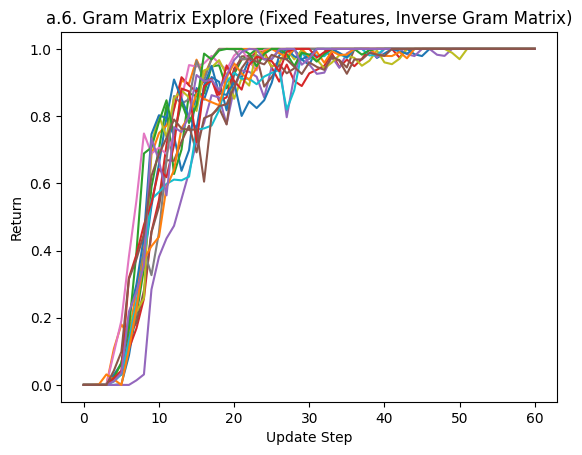

Global Mean: 0.9505998492240906
Global SEM:  0.0033616137225180864


In [ ]:
import time
import matplotlib.pyplot as plt
rng = jax.random.PRNGKey(42)
rngs = jax.random.split(rng, config['N_SEEDS'])
train_vjit = jax.jit(jax.vmap(make_train(config)))
t0 = time.time()
outs = jax.block_until_ready(train_vjit(rngs))
print(f"time: {time.time() - t0:.2f} s")

for i in range(config['N_SEEDS']):
    plt.plot(outs["metrics"]["returned_episode_returns"][i])
plt.xlabel("Update Step")
plt.ylabel("Return")
plt.title('a.6. Gram Matrix Explore (Fixed Features, Inverse Gram Matrix)')
plt.savefig('figures/Fixed Features Gram Matrix.pdf', bbox_inches='tight')
plt.show()

returns = outs["metrics"]["returned_episode_returns"][:, 10:]

# 1. Global Standard Error (Matching your .mean() calculation)
# Uses all 244 points (4 seeds * 61 updates) as samples
sem_global = returns.std() / np.sqrt(returns.size)

print(f"Global Mean: {returns.mean()}")
print(f"Global SEM:  {sem_global}")


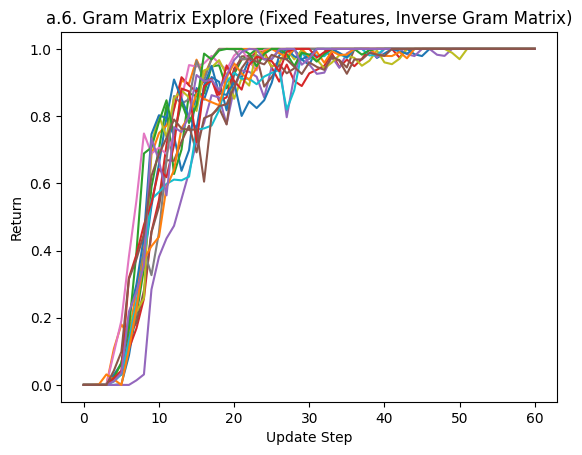

In [4]:
for i in range(config['N_SEEDS']):
    plt.plot(outs["metrics"]["returned_episode_returns"][i])
plt.xlabel("Update Step")
plt.ylabel("Return")
plt.title('a.6. Gram Matrix Explore (Fixed Features, Inverse Gram Matrix)')
plt.savefig('figures/Fixed Features Gram Matrix.pdf', bbox_inches='tight')
plt.show()

KeyError: 'td_error_mean'

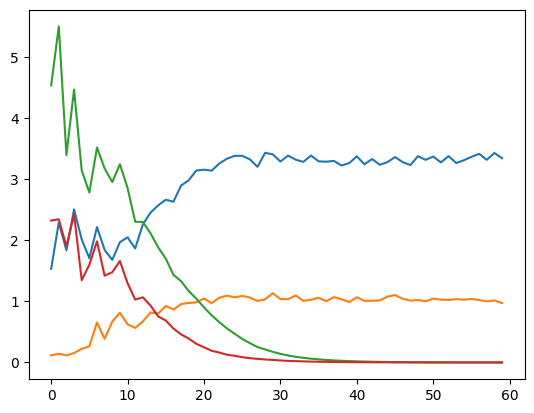

In [3]:
starting_point = 1
plt.plot(outs["metrics"]["feat_norm"][0][starting_point:], label = 'feature norm')
# plt.plot(outs["metrics"]["feat_norm_std"][0][starting_point:], label = 'feature std')
# plt.plot(outs["metrics"]["v_feat_norm"][0][starting_point:], label = 'v feature norm')
# plt.plot(outs["metrics"]["v_feat_norm_std"][0][starting_point:], label = 'v feature std')
# plt.plot(outs["metrics"]["lambda_ret_mean"][0][starting_point:], label = 'lambda_ret_mean')
plt.plot(outs["metrics"]["lambda_ret_std"][0][starting_point:], label = 'lambda_ret_std')
plt.plot(outs["metrics"]["bonus_mean"][0][starting_point:], label = 'bonus_mean')
plt.plot(outs["metrics"]["bonus_std"][0][starting_point:], label = 'bonus_std')
plt.plot(outs["metrics"]["td_error_mean"][0][starting_point:], label = 'td_error_mean')
plt.plot(outs["metrics"]["td_error_std"][0][starting_point:], label = 'td_error_std')
plt.plot(outs["metrics"]["intrinsic_rew_mean"][0][starting_point:], label = 'intrinsic_rew_mean')
plt.plot(outs["metrics"]["max_rew"][0][starting_point:], label = 'max_rew')

# plt.plot(outs["metrics"]["target_embed_mean"].mean(0)[starting_point:], label = 'target_embed_mean')

# Add labels and a title for clarity
plt.xlabel('X Axis Values')
plt.ylabel('Y-axis values')
plt.title('Metrics for LSTD-Explore')
plt.legend()

# Display the plot

# plt.savefig('LSTD_Metrics.pdf', bbox_inches='tight')
plt.show()

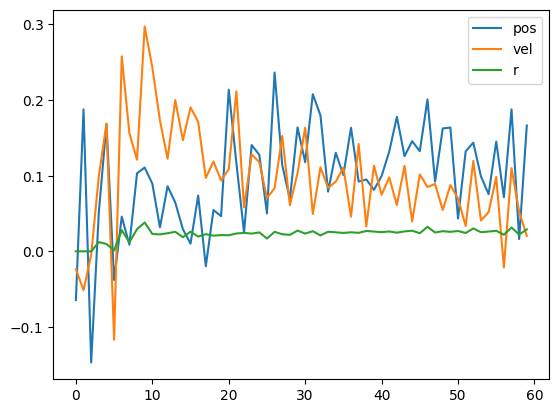

In [ ]:
plt.plot(outs["metrics"]["mean_x"][0][starting_point:], label = 'pos')
plt.plot(outs["metrics"]["mean_v"][0][starting_point:], label = 'vel')
plt.plot(outs["metrics"]["mean_rew"][0][starting_point:], label = 'r')
plt.legend()